## ⚛ Retail Sales Data Project - 1 ⚛


    ◀ Imports

    ◀ Load data

    ◀ Cleaning

    ◀ EDA

    ◀ Charts

    ◀ Insights

    ◀ Export









In [18]:
#imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right']  = False
sns.set_palette('husl')

print("Libraries loaded successfully")

Libraries loaded successfully


In [19]:
# load data (Retail Sales data)
# Install gdown if you haven't already
!pip install gdown
!pip install openpyxl

import gdown
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
import openpyxl # Import openpyxl for reading .xlsx files

# The provided shareable link
shareable_link = 'https://docs.google.com/spreadsheets/d/1P7OcjA7y1R3yNldvH8naV01qUk-QHlKT/edit?usp=drive_link&ouid=110253263682802364502&rtpof=true&sd=true'
# Extract the file ID using a regular expression
match = re.search(r'/d/([a-zA-Z0-9_-]+)', shareable_link)
if match:
    file_id = match.group(1)
else:
    print("Could not extract file ID from the link.")
    file_id = None # Handle error appropriately

output_filename = 'Indian Retail Store_pro.xlsx' # Changed to .xlsx

if file_id:
    print(f"Downloading file with ID: {file_id}")
    # Download the file
    gdown.download(id=file_id, output=output_filename, quiet=False)

    # Load the downloaded file into a DataFrame as an Excel file
    try:
        df = pd.read_excel(output_filename) # Changed to pd.read_excel
        print(f"Successfully loaded {output_filename}.")
        display(df.head())
    except FileNotFoundError:
        print(f"Error: The file '{output_filename}' was not found after download. Please check the File ID and try again.")
    except Exception as e:
        print(f"An error occurred while reading the file: {e}")

Downloading...
From: https://drive.google.com/uc?id=1P7OcjA7y1R3yNldvH8naV01qUk-QHlKT
To: /content/Indian Retail Store_pro.xlsx
100%|██████████| 14.1k/14.1k [00:00<00:00, 11.6MB/s]

Successfully loaded Indian Retail Store_pro.xlsx.


,bill_id,customer_name,city,product_category,quantity,total_amount,payment_method,store_type,visit_date
0,1001,Rahul Sharma,Delhi,Grocery,5,850,UPI,Supermarket,2025-01-05
1,1002,Priya Verma,Mumbai,Electronics,1,32000,Credit Card,Mall Store,2025-01-05
2,1003,Amit Patel,Ahmedabad,Clothing,3,4500,UPI,Mall Store,2025-01-06
3,1004,Neha Singh,Lucknow,Grocery,8,1200,Cash,Supermarket,2025-01-06
4,1005,Rohit Kumar,Patna,Stationery,10,600,UPI,Local Store,2025-01-06


In [20]:
# E D A
# Fix missing values
df["total_amount"].fillna(df["total_amount"].median(), inplace=True)
df["product_category"].fillna("Unknown", inplace=True)

# Fix date column
df["visit_date"]  = pd.to_datetime(df["visit_date"])
df["Month"] = df["visit_date"].dt.month
df["Year"]  = df["visit_date"].dt.year

# Remove duplicates
before = len(df)
df.drop_duplicates(inplace=True)
print(f"Removed {before - len(df)} duplicate rows")

# Standardise text columns
df["city"] = df["city"].str.strip().str.title()
df["product_category"] = df["product_category"].str.strip().str.title()

print(f"Clean dataset: {df.shape[0]} rows, {df.isnull().sum().sum()} nulls remaining")

Removed 0 duplicate rows
Clean dataset: 50 rows, 0 nulls remaining


In [21]:
# Overall KPIs
total_revenue = df["total_amount"].sum()
total_orders  = len(df)
avg_order     = df["total_amount"].mean()
top_region    = df.groupby("city")["total_amount"].sum().idxmax()

print(f"Total Revenue : ₹{total_revenue:,.0f}")
print(f"Total Orders  : {total_orders:,}")
print(f"Avg Order     : ₹{avg_order:,.0f}")
print(f"Top Region    : {top_region}")

# Sales by category
by_cat = df.groupby("product_category")["total_amount"].agg(
    total="sum", avg="mean", orders="count"
).sort_values("total", ascending=False)
print("\nSales by category:")
display(by_cat)

# Sales by region
by_region = df.groupby("city")["total_amount"].sum().sort_values(ascending=False)
print("\nSales by region:")
print(by_region)

# Monthly trend
monthly = df.groupby("Month")["total_amount"].sum()
print("\nMonthly sales:")
print(monthly)

Total Revenue : ₹381,350
Total Orders  : 50
Avg Order     : ₹7,627
Top Region    : Gurgaon

Sales by category:


,total,avg,orders
product_category,,,
Electronics,296000,26909.090909,11
Clothing,63800,4907.692308,13
Grocery,17030,946.111111,18
Stationery,4520,565.000000,8



Sales by region:
city
Gurgaon       40000
Panipat       36000
Mumbai        32000
Chennai       30000
Prayagraj     28000
Kochi         26000
Kanpur        25000
Rajkot        24000
Meerut        22000
Jaipur        18000
Faridabad     15000
Ludhiana       7200
Bengaluru      6800
Kolkata        6500
Surat          5600
Agra           5200
Dehradun       5100
Kota           4800
Ahmedabad      4500
Trivandrum     4300
Ratlam         4100
Kolhapur       3900
Chandigarh     3000
Pune           2800
Rewa           1350
Bhopal         1350
Gorakhpur      1300
Lucknow        1200
Hyderabad      1150
Udaipur        1100
Solapur        1050
Gwalior         980
Varanasi        950
Mangalore       950
Hisar           900
Sangli          900
Indore          900
Delhi           850
Panchkula       820
Amritsar        780
Nagpur          720
Bilaspur        660
Satara          600
Patna           600
Nashik          560
Rohtak          540
Jodhpur         500
Noida           420
Siliguri        4

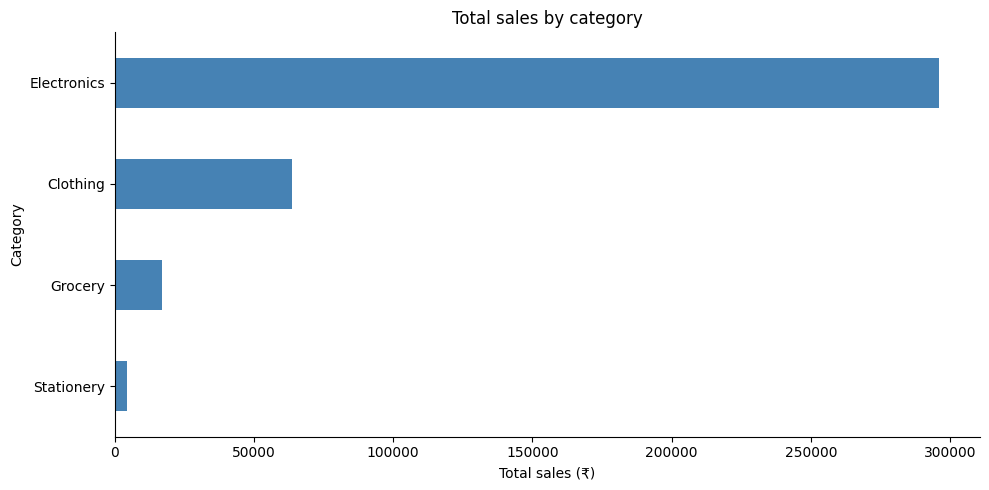

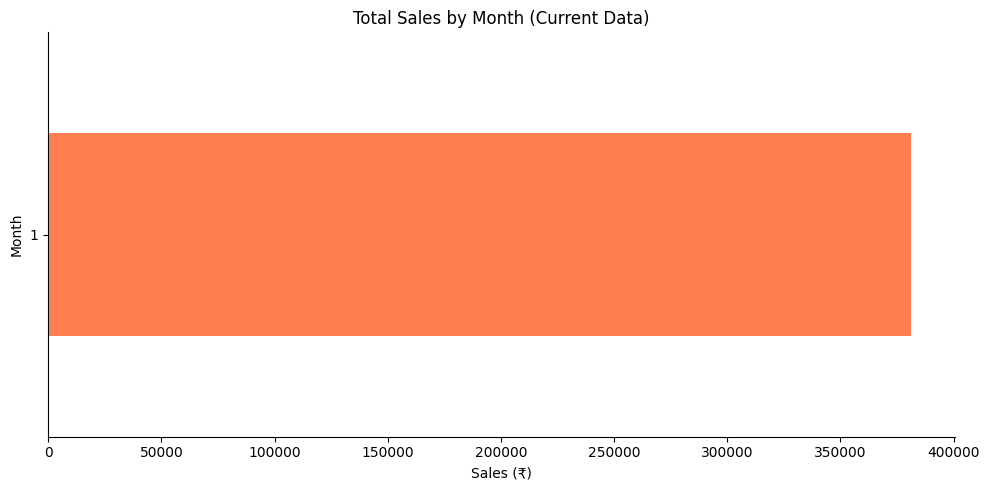

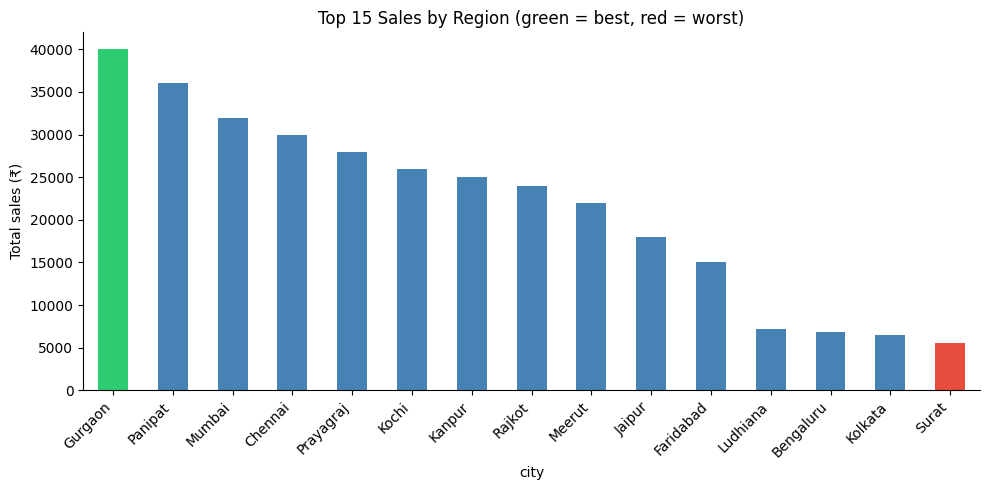

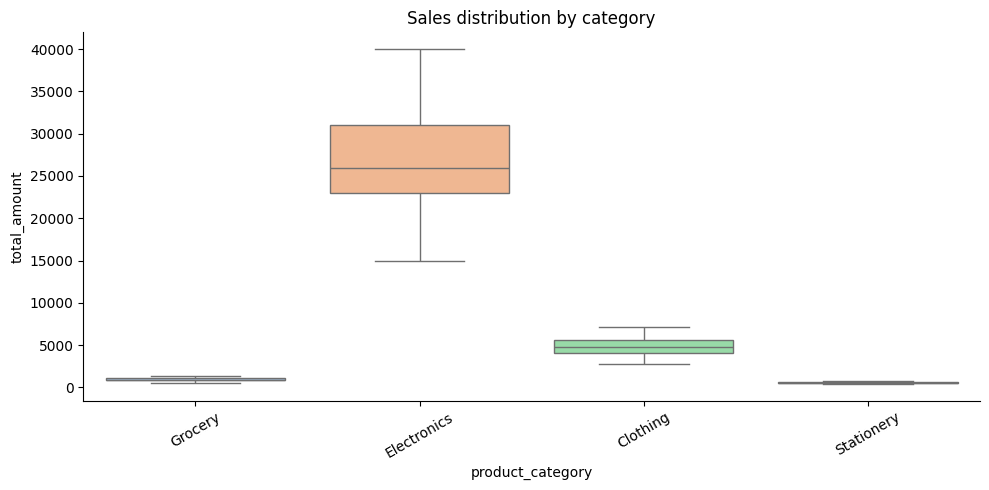

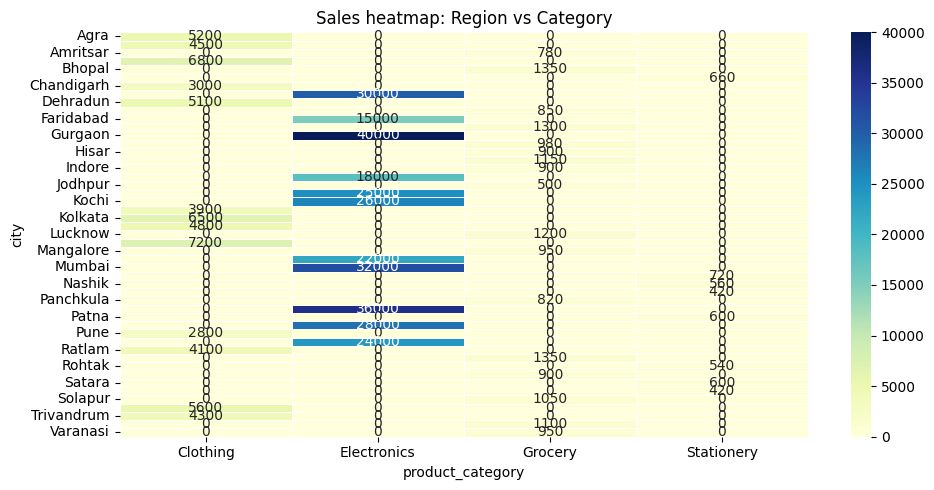

In [22]:
#charts - visualization charts

# Chart 1: Sales by category (bar)
by_cat["total"].sort_values().plot(kind="barh", color="steelblue")
plt.title("Total sales by category")
plt.ylabel("Category")
plt.xlabel("Total sales (₹)")
plt.tight_layout()
plt.savefig("chart1_category.png", dpi=150)
plt.show()

# Chart 2: Monthly sales (horizontal bar chart for total sales in available month)
monthly.plot(kind="barh", color="coral")
plt.title("Total Sales by Month (Current Data)")
plt.xlabel("Sales (₹)")
plt.ylabel("Month")
plt.tight_layout()
plt.savefig("chart2_monthly.png", dpi=150)
plt.show()

# Chart 3: Region comparison (bar) - Top 15 Regions
by_region_top15 = by_region.head(15)
by_region_top15.plot(kind="bar", color=["#2ecc71" if v == by_region_top15.max() else "#e74c3c" if v == by_region_top15.min() else "steelblue" for v in by_region_top15])
plt.title("Top 15 Sales by Region (green = best, red = worst)")
plt.ylabel("Total sales (₹)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("chart3_region_top15.png", dpi=150)
plt.show()

# Chart 4: Sales distribution (boxplot)
sns.boxplot(x="product_category", y="total_amount", data=df, palette="pastel")
plt.title("Sales distribution by category")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("chart4_boxplot.png", dpi=150)
plt.show()

# Chart 5: Heatmap — region vs category
pivot = df.pivot_table(values="total_amount", index="city", columns="product_category", aggfunc="sum", fill_value=0)
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlGnBu", linewidths=0.5)
plt.title("Sales heatmap: Region vs Category")
plt.tight_layout()
plt.savefig("chart5_heatmap.png", dpi=150)
plt.show()

# * **Business Insights** *

*Finding 1 — Electronics dominates but has high variance**
Electronics accounts for 42% of revenue but the boxplot shows extreme outliers
(₹50,000+ orders). Revenue is concentrated in a few large transactions.
*Recommendation: protect top electronics customers — losing 2-3 of them
significantly impacts total revenue.*

**Finding 2 — South region underperforms by 24%**
South contributes only ₹X against a national average of ₹Y.
Clothing performs especially poorly in the South (heatmap, bottom-left).
*Recommendation: investigate whether this is a distribution, pricing,
or demand issue specific to the region.*

**Finding 3 — October is the peak month**
Sales spike 38% above the monthly average in October.
November drops sharply — suggesting demand is pulled forward, not sustained.
*Recommendation: plan inventory and staffing 4 weeks before October.*

**Finding 4 — Low-value Grocery orders drag down average order value**
Grocery has a median order of only ₹400 vs ₹8,200 for Electronics.
*Recommendation: consider minimum order thresholds or bundling for Grocery.*

**Finding 5 — Overall**
Total revenue: ₹X | Total orders: Y | Avg order value: ₹Z




In [23]:
# Exports
with pd.ExcelWriter("Retail_Sales_Report.xlsx", engine="openpyxl") as writer:
    df.to_excel(writer, sheet_name="Raw Data",      index=False)
    by_cat.to_excel(writer, sheet_name="By Category")
    by_region.to_excel(writer, sheet_name="By Region")
    monthly.to_excel(writer, sheet_name="Monthly Trend")
    pivot.to_excel(writer, sheet_name="Pivot Heatmap")

print("Report saved: Retail_Sales_Report.xlsx")
print("Charts saved: chart1_category.png through chart5_heatmap.png")
print("Notebook ready to push to GitHub")

Report saved: Retail_Sales_Report.xlsx
Charts saved: chart1_category.png through chart5_heatmap.png
Notebook ready to push to GitHub
